In [230]:
import numpy as np
import pandas as pd
import os
import time
import json 
import warnings
from scipy.stats import t as t_dist
from arch import arch_model
import yfinance as yf

In [231]:
random_seed=(42)

stock_prices=pd.read_csv("GARCH.csv",  delimiter=",")

In [232]:
stock_prices=pd.read_csv('gbm_stock_paths_vol.csv', delimiter=",")

In [233]:
branson=pd.read_csv("black_scholes_simulation_data_T5.csv",  delimiter=",")

In [234]:
branson["S"]=stock_prices["price"]

In [235]:
branson["sigma"]=stock_prices["sigma"]

In [236]:
branson.head()

,simulation,day,S,K,T,sigma,r
0,0,0,8173.000000,9807.6,5.000000,0.037076,4.380503
1,0,1,8169.017012,9807.6,4.996032,0.037076,4.450401
2,0,2,8165.447324,9807.6,4.992063,0.037076,4.472661
3,0,3,8191.336522,9807.6,4.988095,0.037076,4.484400
4,0,4,8213.832666,9807.6,4.984127,0.037076,4.495323


In [237]:
strikes = 8173 * np.random.choice(np.arange(0.6, 1.6, 0.1), size=10000)
branson['K'] = np.repeat(strikes, branson.groupby('simulation').size().values)

In [238]:
df=branson

In [239]:
df["r"]=df["r"]/100

In [240]:
df.shape

(12600000, 7)

In [241]:
from scipy.stats import norm
def bs_call_chunked(S, K, T, r, sigma, chunk_size=10_000_000):
    result = np.zeros(len(S))
    for start in range(0, len(S), chunk_size):
        end = min(start + chunk_size, len(S))
        s = S[start:end]
        k = K[start:end]
        t = T[start:end]
        rv = r[start:end]       # <-- slice r too
        sig = sigma[start:end]
        mask = t > 1e-10
        price = np.maximum(s - k, 0)
        if np.any(mask):
            Sv = np.where(mask, s, 1)
            Kv = np.where(mask, k, 1)
            Tv = np.where(mask, t, 1)
            sv = np.where(mask, sig, 0.2)
            d1 = (np.log(Sv/Kv) + (rv + 0.5*sv**2)*Tv) / (sv*np.sqrt(Tv))
            d2 = d1 - sv*np.sqrt(Tv)
            price = np.where(mask, Sv*norm.cdf(d1) - Kv*np.exp(-rv*Tv)*norm.cdf(d2), price)
        result[start:end] = price
    return result
df['call_price'] = bs_call_chunked(
    df['S'].values, df['K'].values, df['T'].values, 
    df['r'].values, df['sigma'].values
)

print(f"Data: {len(df):,} rows | {df['simulation'].nunique():,} sims | call_price mean={df['call_price'].mean():.1f}")

Data: 12,600,000 rows | 10,000 sims | call_price mean=2681.5


In [242]:
df.head()

,simulation,day,S,K,T,sigma,r,call_price
0,0,0,8173.000000,8173.0,5.000000,0.037076,0.043805,1608.393542
1,0,1,8169.017012,8173.0,4.996032,0.037076,0.044504,1626.075229
2,0,2,8165.447324,8173.0,4.992063,0.037076,0.044727,1628.601989
3,0,3,8191.336522,8173.0,4.988095,0.037076,0.044844,1657.068036
4,0,4,8213.832666,8173.0,4.984127,0.037076,0.044953,1681.888511


In [243]:
df = df[df["T"]>1]

In [244]:

#LSTM training function + hyperparameter tuning

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


def build_sequences(df, seq_len, features, cache_prefix):
    """Sliding-window sequences, cached to disk."""
    xf, yf = f'{cache_prefix}_X.npy', f'{cache_prefix}_y.npy'
    if os.path.exists(xf):
        return np.load(xf), np.load(yf)

    df = df.sort_values(['simulation','day']).reset_index(drop=True)
    sims = df['simulation'].unique()
    n_sims, dps = len(sims), len(df) // len(sims)
    sps, nf = dps - seq_len, len(features)
    X = np.zeros((n_sims * sps, seq_len, nf), dtype=np.float32)
    y = np.zeros(n_sims * sps, dtype=np.float32)
    feat = df[features].values.astype(np.float32)
    tgt  = df['call_price'].values.astype(np.float32)
    idx = 0
    for s in tqdm(range(n_sims), desc="Building sequences", leave=False):
        off = s * dps
        sf, st = feat[off:off+dps], tgt[off:off+dps]
        for i in range(seq_len, dps):
            X[idx], y[idx] = sf[i-seq_len:i], st[i]; idx += 1
    np.save(xf, X); np.save(yf, y)
    return X, y


def make_model(input_size, hidden, layers, drop, fc_sizes):
    """Simple LSTM → FC head."""
    class M(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden, layers, batch_first=True,
                                dropout=drop if layers > 1 else 0)
            mods = []
            prev = hidden
            for sz in fc_sizes:
                mods += [nn.Linear(prev, sz), nn.ReLU(), nn.Dropout(drop)]; prev = sz
            mods.append(nn.Linear(prev, 1))
            self.head = nn.Sequential(*mods)
            for n, p in self.lstm.named_parameters():
                nn.init.xavier_uniform_(p) if 'weight' in n else nn.init.zeros_(p)
            for m in self.head:
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
        def forward(self, x):
            o, _ = self.lstm(x)
            out = self.head(o[:, -1, :]).squeeze(-1)
            return out
          
    return M()


def train_lstm(df, *, seq_len=50, features=('S','sigma','T','K',"r"),
               train_split=.7, val_split=.15,
               hidden=128, layers=3, drop=.2, fc=(64,),
               bs=256, lr=1e-3, epochs=50, patience=10, wd=1e-5, clip=1.0,
               seed=42, save_dir='lstm_out', cache='seq'):
    """
    Full pipeline: sequences → scale → train → evaluate → plots.
    Returns (model, history_dict, metrics_dict, scalers_dict).
    """
    torch.manual_seed(seed); np.random.seed(seed)
    os.makedirs(save_dir, exist_ok=True)
    features = list(features); nf = len(features)

    # --- sequences ---
    X, y = build_sequences(df, seq_len, features, cache)

    # --- split by simulation ---
    n_sims = df['simulation'].nunique()
    sps = len(X) // n_sims
    tr = int(train_split * n_sims) * sps
    va = int(val_split  * n_sims) * sps
    Xtr, ytr = X[:tr], y[:tr]
    Xva, yva = X[tr:tr+va], y[tr:tr+va]
    Xte, yte = X[tr+va:], y[tr+va:]
    print(f"  Split: train={len(Xtr):,}  val={len(Xva):,}  test={len(Xte):,}")

    # --- scale ---
    sx = StandardScaler()
    Xtr_s = sx.fit_transform(Xtr.reshape(-1,nf)).reshape(Xtr.shape)
    Xva_s = sx.transform(Xva.reshape(-1,nf)).reshape(Xva.shape)
    Xte_s = sx.transform(Xte.reshape(-1,nf)).reshape(Xte.shape)
    sy = StandardScaler()
    ytr_s = sy.fit_transform(ytr.reshape(-1,1)).ravel()
    yva_s = sy.transform(yva.reshape(-1,1)).ravel()
    yte_s = sy.transform(yte.reshape(-1,1)).ravel()

    pin = torch.cuda.is_available()
    mk = lambda X, y, shuf: DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y)), bs, shuffle=shuf, pin_memory=pin)
    trl, val, tel = mk(Xtr_s, ytr_s, True), mk(Xva_s, yva_s, False), mk(Xte_s, yte_s, False)

    # --- model ---
    model = make_model(nf, hidden, layers, drop, list(fc)).to(device)
    crit = nn.MSELoss()
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=.5, patience=5, min_lr=1e-7)
    npar = sum(p.numel() for p in model.parameters())
    print(f"  Model: hidden={hidden} layers={layers} drop={drop} fc={list(fc)} params={npar:,}")

    # --- train ---
    hist = {'train':[], 'val':[], 'lr':[]}
    best_vl, wait, best_w = float('inf'), 0, None
    print(f"  {'Ep':<4} {'Train':<11} {'Val':<11} {'LR':<13} Status")

    for ep in range(1, epochs+1):
        # train
        model.train(); tot, n = 0, 0
        for bx, by in tqdm(trl, leave=False, desc='train'):
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad(); loss = crit(model(bx), by); loss.backward()
            if clip: torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step(); tot += loss.item(); n += 1
        tl = tot / n
        # val
        model.eval(); tot, n = 0, 0
        with torch.no_grad():
            for bx, by in tqdm(val, leave=False, desc='val'):
                tot += crit(model(bx.to(device)), by.to(device)).item(); n += 1
        vl = tot / n
        hist['train'].append(tl); hist['val'].append(vl)
        hist['lr'].append(opt.param_groups[0]['lr'])
        sched.step(vl)
        if vl < best_vl:
            best_vl, wait = vl, 0; best_w = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_w, f'{save_dir}/best.pth'); s = '✓'
        else:
            wait += 1; s = f'wait {wait}/{patience}'
        print(f"  {ep:<4} {tl:<11.6f} {vl:<11.6f} {opt.param_groups[0]['lr']:<13.2e} {s}")
        if wait >= patience: print('  Early stop'); break

    if best_w: model.load_state_dict(best_w)

    # --- evaluate ---
    model.eval(); preds, acts = [], []
    with torch.no_grad():
        for bx, by in tqdm(tel, leave=False, desc='test'):
            preds.extend(model(bx.to(device)).cpu().numpy()); acts.extend(by.numpy())
    yt = sy.inverse_transform(np.array(acts).reshape(-1,1)).ravel()
    yp = sy.inverse_transform(np.array(preds).reshape(-1,1)).ravel()
    yp = np.clip(yp, 0, None)
    mse = mean_squared_error(yt, yp); mask = yt != 0
    met = {'wMAPE':  np.sum(np.abs(yt - yp)) / np.sum(np.abs(yt)) * 100,
           'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': mean_absolute_error(yt, yp)
            }
    print(f"\n  TEST   wMAPE={met['wMAPE']:.1f}  RMSE={met['RMSE']:.1f}")

    # --- plots ---
    fig, ax = plt.subplots(1,2,figsize=(13,4))
    ax[0].plot(hist['train'],label='train'); ax[0].plot(hist['val'],label='val')
    ax[0].set(xlabel='Epoch',ylabel='Loss',title='Loss'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist['lr'],c='green'); ax[1].set(xlabel='Epoch',ylabel='LR',title='LR',yscale='log'); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f'{save_dir}/loss.png',dpi=150); plt.show()

    fig, ax = plt.subplots(1,2,figsize=(13,5))
    idx = np.random.choice(len(yt), min(1000,len(yt)), replace=False)
    ax[0].scatter(yt[idx],yp[idx],s=8,alpha=.4)
    ax[0].plot([yt.min(),yt.max()],[yt.min(),yt.max()],'r--')
    ax[0].set(xlabel='True',ylabel='Pred',title='Pred vs True'); ax[0].grid(alpha=.3)
    ax[1].hist(yp-yt,bins=50,alpha=.7,ec='k'); ax[1].axvline(0,c='r',ls='--')
    ax[1].set(xlabel='Error',ylabel='Freq',title='Errors'); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f'{save_dir}/preds.png',dpi=150); plt.show()
    
    return model, hist, met, {'sx':sx, 'sy':sy}

Device: cpu


In [245]:
df_small = df[df['simulation'] < 1000]

In [246]:
df_small.shape

(1008000, 8)

  Split: train=670,600  val=143,700  test=143,700
  Model: hidden=64 layers=2 drop=0.2 fc=[32] params=53,569
  Ep   Train       Val         LR            Status


  1    0.045527    0.004729    1.00e-03      ✓


  2    0.023806    0.004700    1.00e-03      ✓


  3    0.023003    0.005645    1.00e-03      wait 1/5



  TEST   wMAPE=4.6  RMSE=247.7


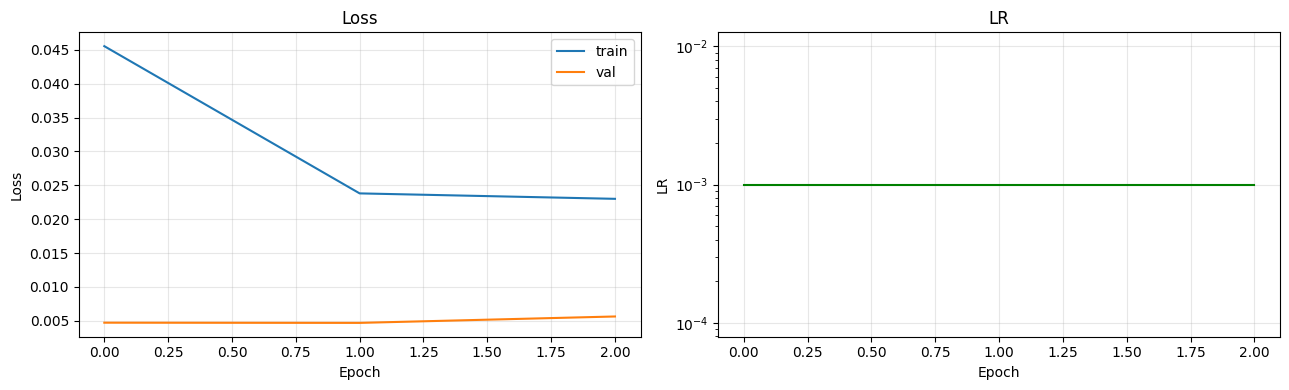

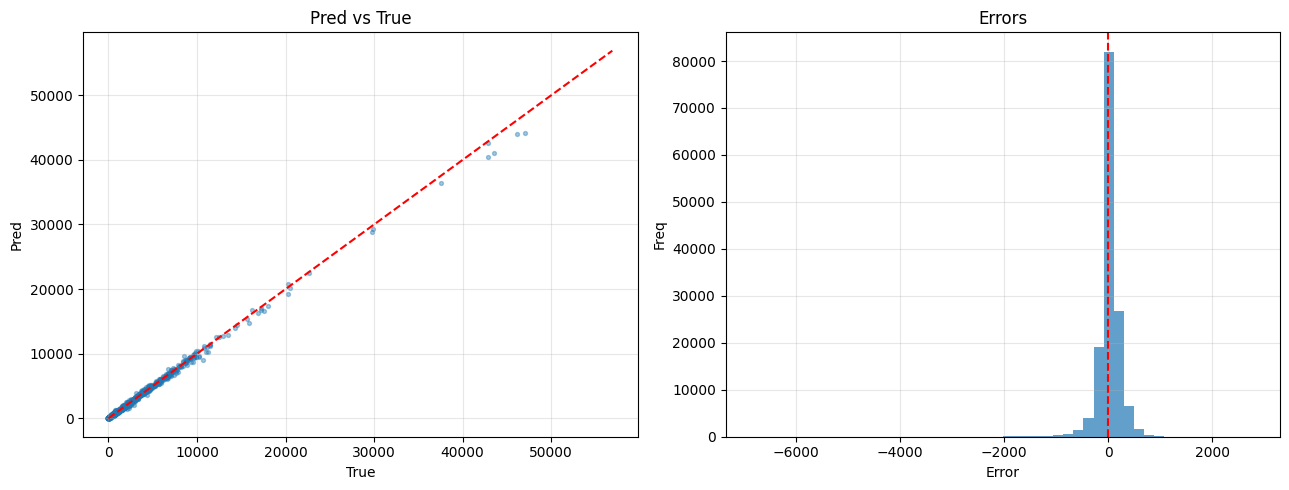

In [247]:
model, hist, met, scalers = train_lstm(
    df_small, hidden=64, layers=2, fc=(32,),
    bs=512, lr=1e-3, epochs=3,patience=5,
    save_dir='lstm_test', cache='seq_test')

In [ ]:

# =============================================================================
# CELL 5 (optional): Grid search
# =============================================================================
def grid_search(df, grid, subset=1000, save_dir='grid'):
    os.makedirs(save_dir, exist_ok=True)
    df_t = df[df['simulation'] < subset].copy()
    combos = [dict(zip(grid, v)) for v in itertools.product(*grid.values())]
    print(f"Grid search: {len(combos)} configs on {subset} sims\n")
    rows = []
    for i, c in enumerate(combos):
        print(f"--- [{i+1}/{len(combos)}] {c}")
        t0 = time.time()
        try:
            _, _, m, _ = train_lstm(
                df_t, hidden=c['hidden_size'], layers=c['num_layers'],
                drop=c['dropout'], fc=(c['hidden_size']//2,),
                bs=c['batch_size'], lr=c['learning_rate'],
                epochs=c.get('epochs',20), patience=5,
                save_dir=f'{save_dir}/t{i}', cache=f'seq_gs_{subset}')
            rows.append({**c, **m, 'time': (time.time()-t0)/60})
        except Exception as e:
            print(f"  FAIL: {e}"); rows.append({**c, 'R2': None})
    rdf = pd.DataFrame(rows); rdf.to_csv(f'{save_dir}/results.csv', index=False)
    ok = rdf.dropna(subset=['R2'])
    if len(ok):
        b = ok.loc[ok['R2'].idxmax()]
        print(f"\nBest R²={b['R2']:.6f}:"); [print(f"  {k}: {b[k]}") for k in grid]
    return rdf

# Example:
# grid_search(df, {
#     'hidden_size': [64, 128],
#     'num_layers':  [2, 3],
#     'dropout':     [0.2, 0.3],
#     'learning_rate': [1e-3, 2e-3],
#     'batch_size':  [256, 512],
# })